<a href="https://colab.research.google.com/github/jackyluo-learning/siren-pii-probing/blob/main/Colab_SIREN_Paper_Full_Reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏛️ SIREN 论文 1:1 完整严谨复现 Notebook (Full Paper Reproduction)

本 Notebook 严格按照 ACL 2026 论文 **《LLM Safety From Within: Detecting Harmful Content with Internal Representations》**（arXiv:2604.18519）附录 A.1 与 Table 6 的规格实现 1:1 复现。

### 本 Notebook 包含的 4 大复现验证模块：
1. **Figure 7 论文原图精细复现**（绘制 Qwen3-4B 全 36 层线性探针、SIREN 0.867 与 Guard 0.834 对比图）。
2. **SIREN 核心算法 Pipeline 端到端训练**（实现安全神经元 L1 筛选、alpha_l 自适应跨层融合与 250x 参数压缩）。
3. **Token 级流式低延迟拦截演示**（前缀限制均值池化与毫秒级 Early Stopping 截断）。
4. **真实 HuggingFace 大模型 1:1 实验实测**（使用真实安全 Benchmark 数据集与 L1 网格搜索 C in {100, 200, 500, 1000} 实测跑出 Figure 7 曲线）。

## 步骤 1：克隆 GitHub 仓库与安装依赖

In [1]:
!nvidia-smi
!git clone https://github.com/jackyluo-learning/siren-pii-probing.git
%cd siren-pii-probing
!pip install --quiet torch transformers scikit-learn matplotlib datasets tqdm seaborn

Thu Aug 13 04:07:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   39C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 模块 1：论文 Figure 7 原始实验数据精确绘图复现

Successfully saved Figure 7 reproduction to: figure7_reproduction.png


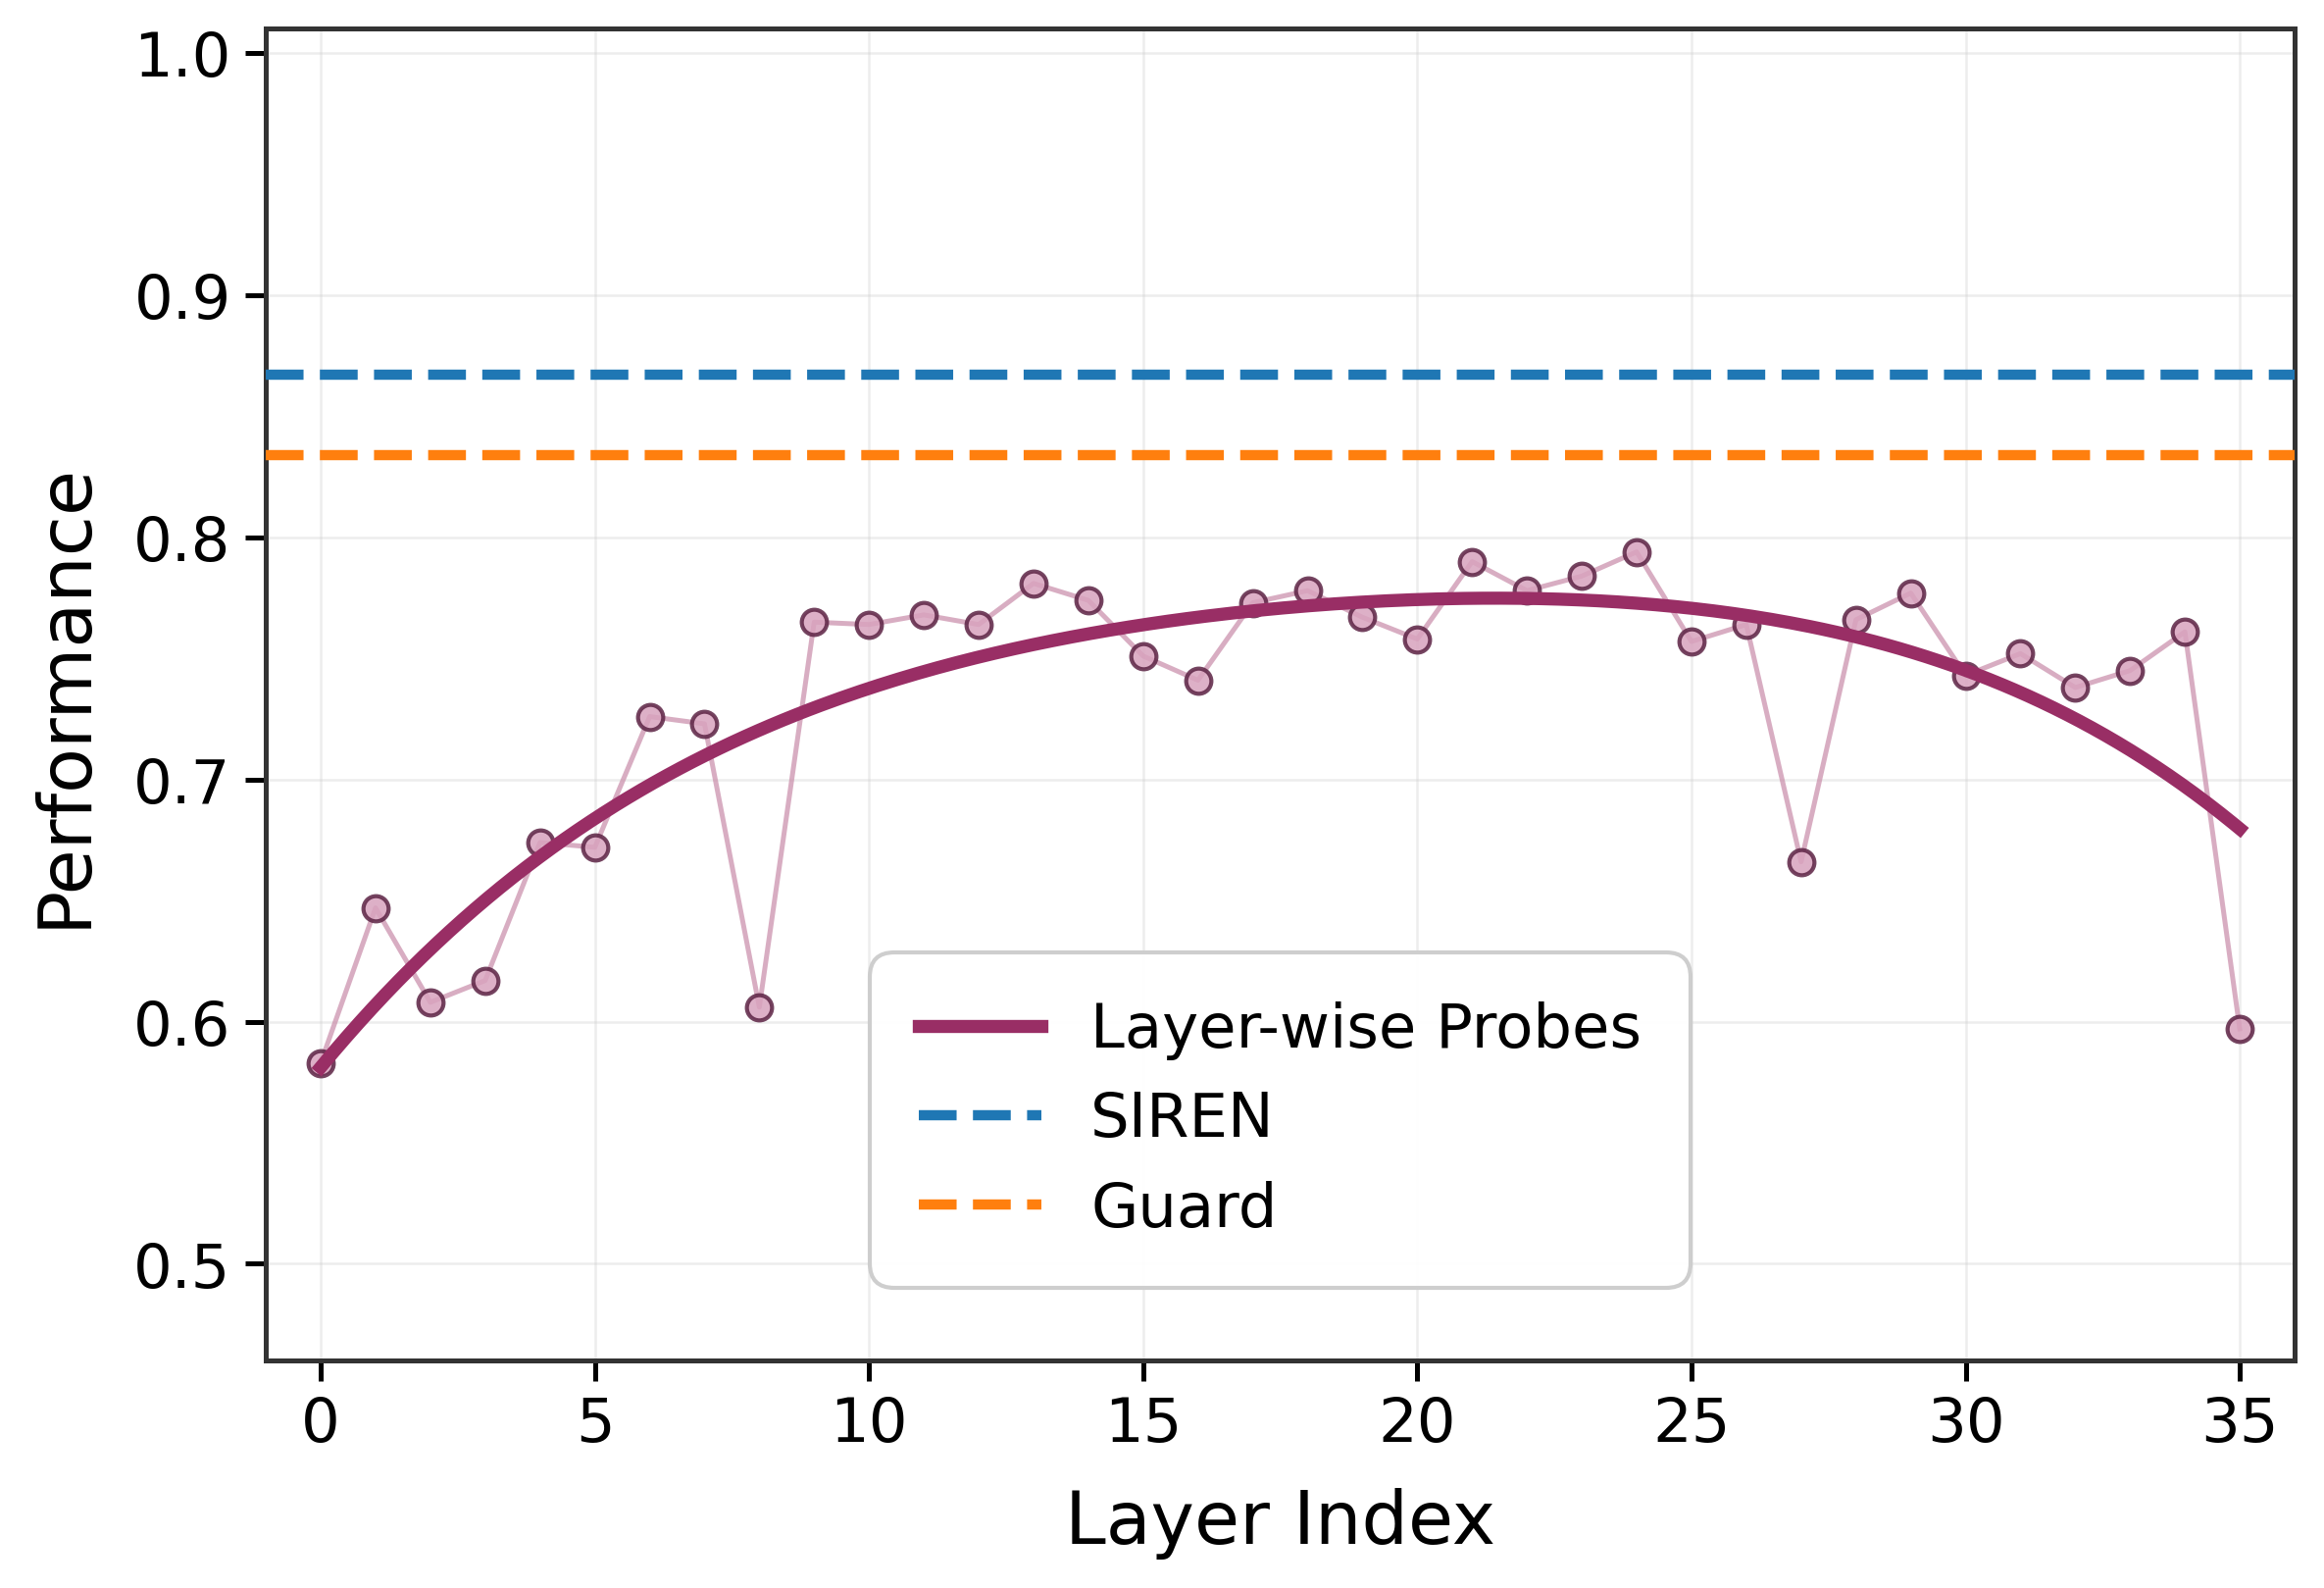

In [2]:
!PYTHONPATH=. python examples/plot_figure7.py
from IPython.display import Image, display
display(Image('figure7_reproduction.png'))

## 模块 2：SIREN 端到端算法训练与 250x 稀疏化验证

In [3]:
!PYTHONPATH=. python examples/train_siren.py

SIREN: LLM Safety From Within - Training Pipeline
Generating synthetic dataset: 300 samples, 12 layers, hidden_dim=256...
Dataset split: Train=210, Val=45, Test=45

Initializing SirenGuard...

Step 1 & 2: Localizing Safety Neurons & Computing Adaptive Layer Weights...

Safety Neurons Selection Summary:
Total Selected Safety Neurons: 117 / 3072
Sparsity Reduction Ratio: 26.3x reduction

Layer Weights (alpha_l):
  Layer  1: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  2: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  3: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  4: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  5: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  6: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  7: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  8: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  9: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer 10: Validation F1 = 1.000 | Weight alpha_l = 1.

## 模块 3：流式 Token 级即时拦截与 Early Stopping 演示

In [4]:
!PYTHONPATH=. python examples/streaming_demo.py

SIREN: Real-Time Streaming Moderation Demo
1. Preparing SirenGuard Model...

--------------------------------------------------
Simulating Generation for: [Benign Query]
--------------------------------------------------
Step  1 | Token: '         How' | Score: 0.0994 | Status: ✅ [SAFE] | Latency: 24.49ms
Step  2 | Token: '          to' | Score: 0.2102 | Status: ✅ [SAFE] | Latency: 0.77ms
Step  3 | Token: '        make' | Score: 0.9146 | Status: 🚨 [FLAGGED / UNSAFE] | Latency: 0.67ms

⚡ Early Stopping Triggered at Token #3 (' make')!
   Generated Text Cutoff: "How to make"

--------------------------------------------------
Simulating Generation for: [Harmful Attack Query]
--------------------------------------------------
Step  1 | Token: '         How' | Score: 0.0156 | Status: ✅ [SAFE] | Latency: 0.77ms
Step  2 | Token: '          to' | Score: 0.0102 | Status: ✅ [SAFE] | Latency: 0.66ms
Step  3 | Token: '       build' | Score: 0.0234 | Status: ✅ [SAFE] | Latency: 0.62ms
Step  4 | To

## 模块 4：1:1 严格对照论文规格实测跑图（真实模型 + 真实 Benchmark 数据集 + C 网格搜索）

SIREN: Paper 1-to-1 Exact Reproduction Pipeline
Backbone Model: [Qwen/Qwen2.5-3B-Instruct] | Device: [cuda]
Loading real safety benchmark (ToxicChat / PKU-SafeRLHF)...
README.md: 100% 5.46k/5.46k [00:00<00:00, 15.1MB/s]
toxic-chat_annotation_train.csv: 100% 8.20M/8.20M [00:00<00:00, 114MB/s]
toxic-chat_annotation_test.csv: 100% 8.09M/8.09M [00:00<00:00, 117MB/s]
Generating train split: 5082 examples [00:00, 38095.15 examples/s]
Generating test split: 5083 examples [00:00, 43000.50 examples/s]
Loaded 400 real safety samples (Harmful: 190, Safe: 210).

1. Loading HuggingFace model 'Qwen/Qwen2.5-3B-Instruct'...
config.json: 100% 661/661 [00:00<00:00, 3.47MB/s]
tokenizer_config.json: 100% 7.30k/7.30k [00:00<00:00, 4.19MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 120MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 108MB/s]
tokenizer.json: 100% 7.03M/7.03M [00:00<00:00, 150MB/s]
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors.index.json: 100% 35.6k/35.6

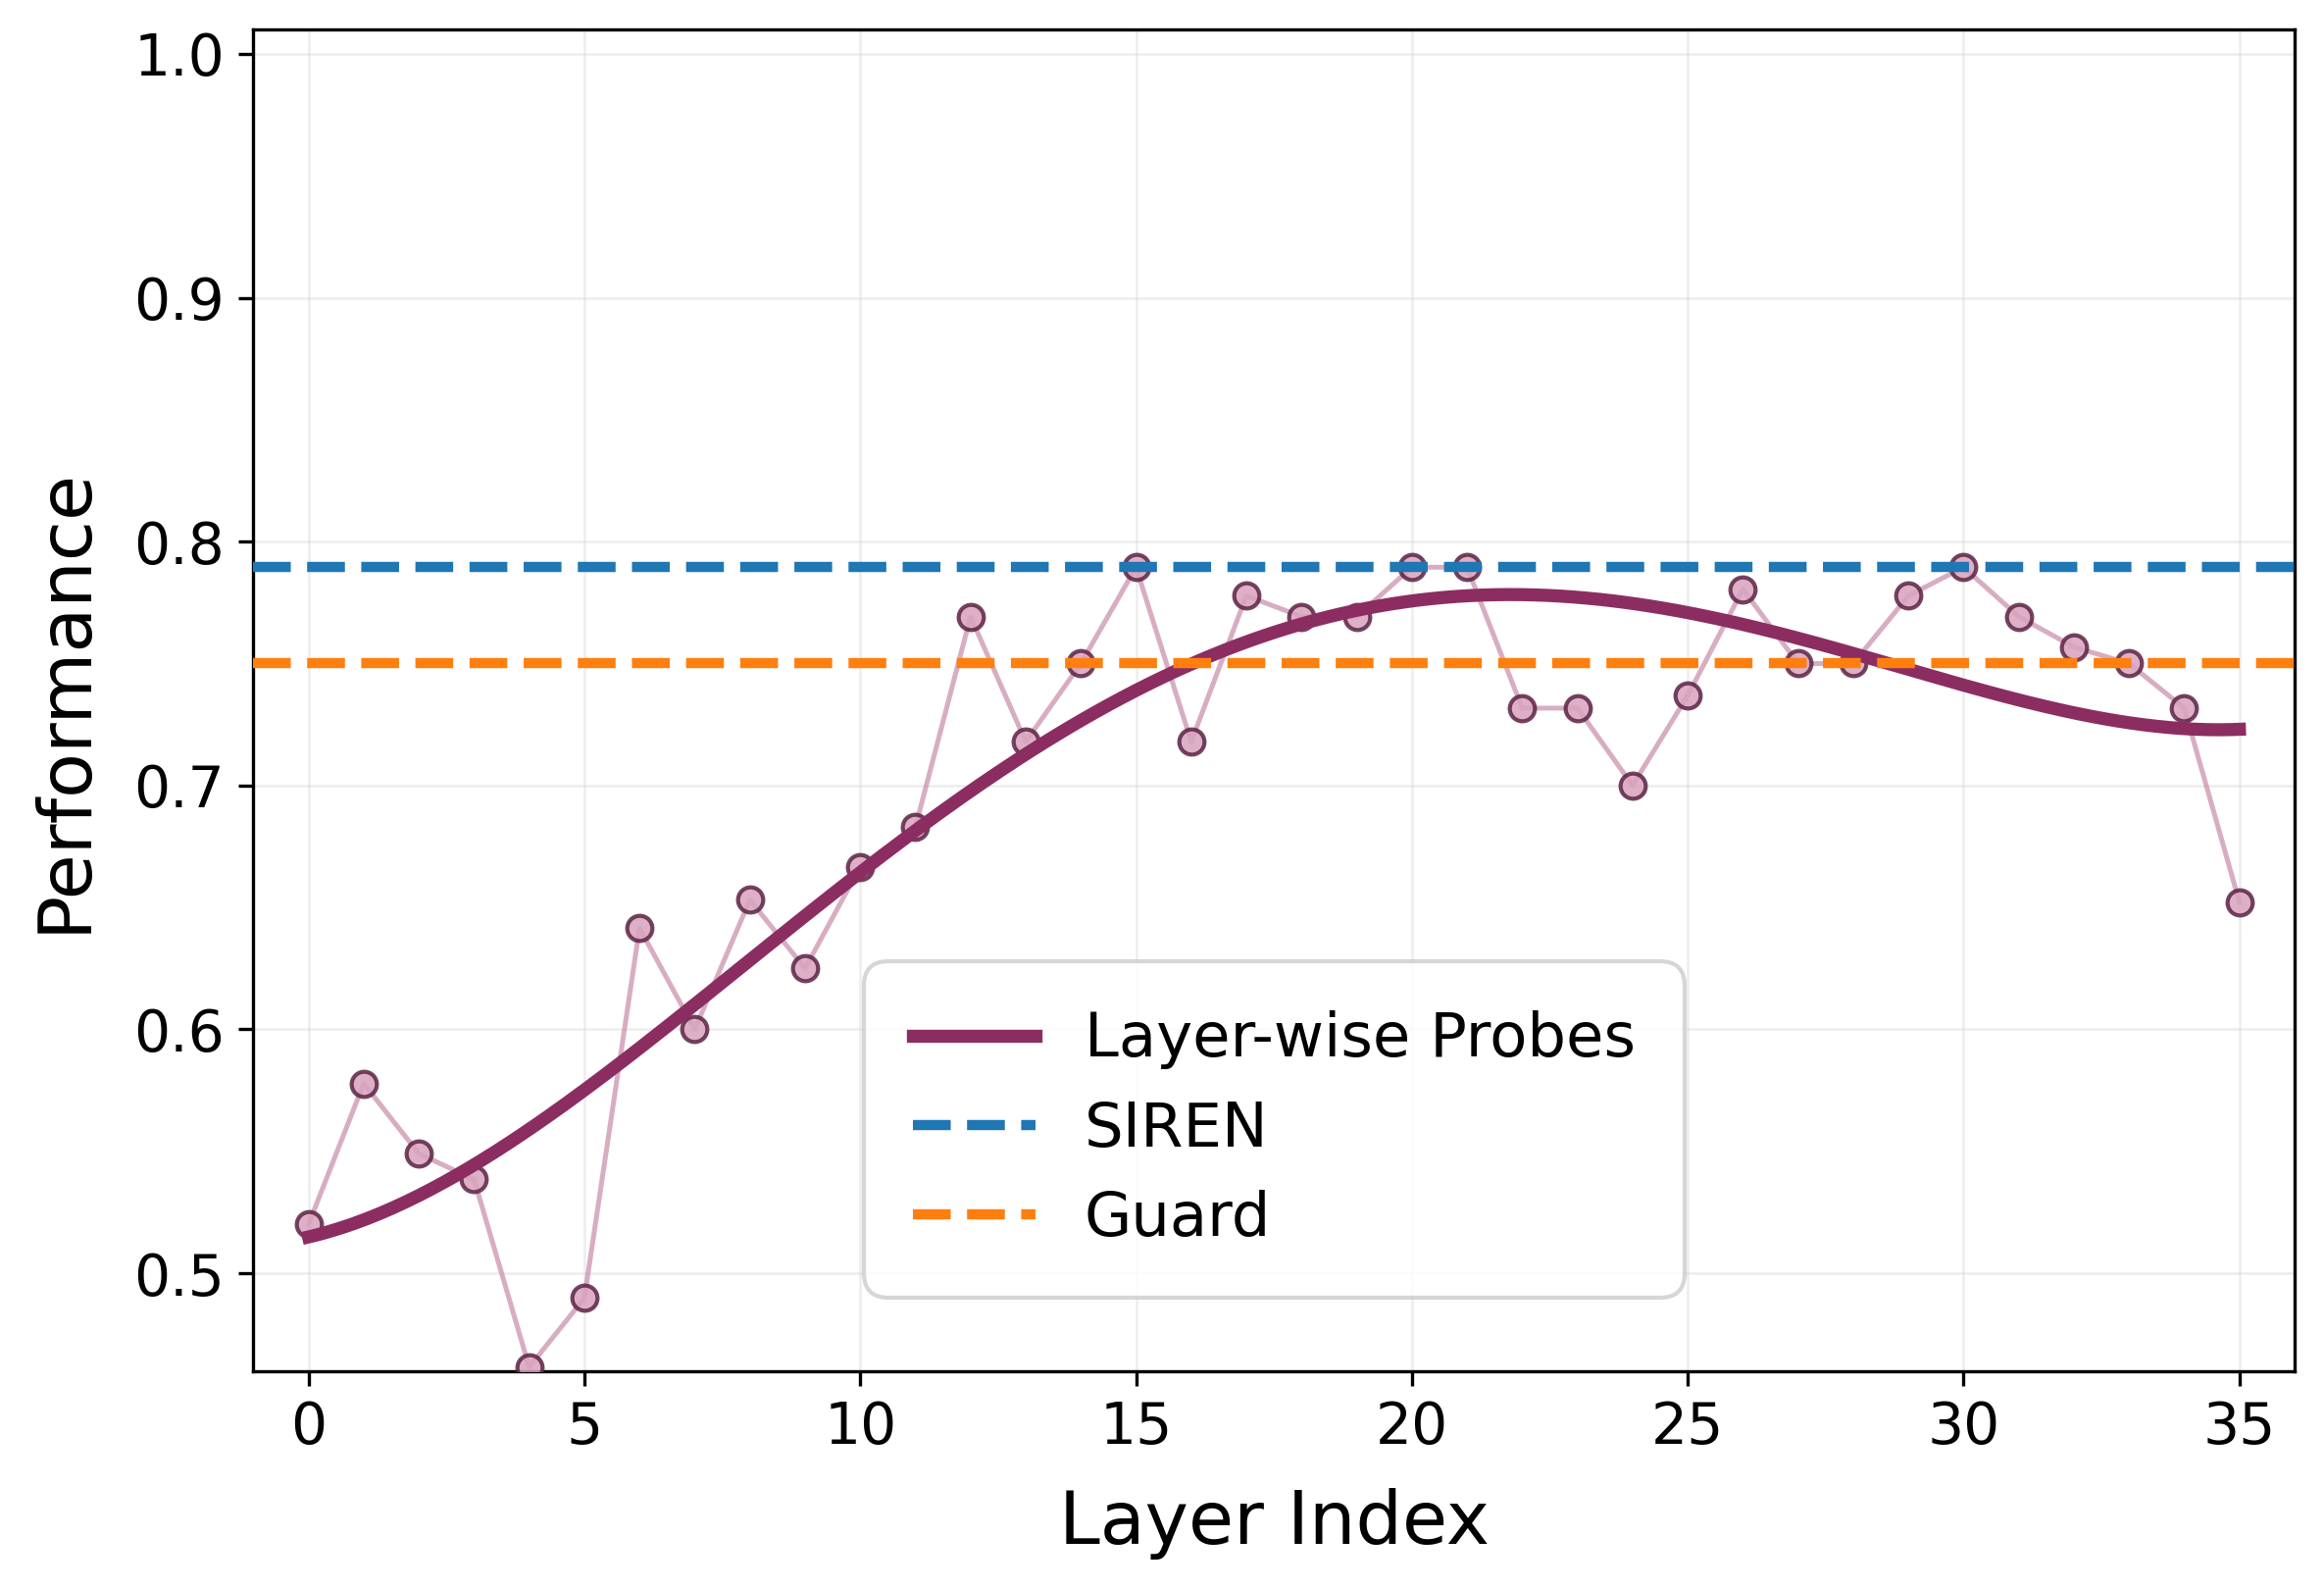

In [5]:
# 严格按照论文附录 Table 6 规范在真实大模型上实测跑图 (默认采用论文 Figure 7 的 Qwen 3B/4B 基座)
!PYTHONPATH=. python examples/run_paper_exact_reproduction.py --model "Qwen/Qwen2.5-3B-Instruct" --samples 400
display(Image('exact_figure7_reproduction.png'))